In [12]:
# ============================================================
#  TELECOM CUSTOMER CHURN ANALYSIS
#  Phase 3 — Data Preprocessing & Feature Engineering
#  Dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
 

In [13]:
# ─────────────────────────────────────────────────────────────
#  STEP 1 — Load & basic fix (same as Phase 1)
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('telco_churn_cleaned.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
 
print("✅ Data loaded")
print(f"   Shape: {df.shape}\n")

✅ Data loaded
   Shape: (7043, 21)



In [14]:
# ─────────────────────────────────────────────────────────────
#  STEP 2 — Drop customerID (not a feature)
# ─────────────────────────────────────────────────────────────
df.drop('customerID', axis=1, inplace=True)
print("✅ Dropped customerID column")
print(f"   Shape after drop: {df.shape}\n")
 

✅ Dropped customerID column
   Shape after drop: (7043, 20)



In [15]:
# ─────────────────────────────────────────────────────────────
#  STEP 3 — Encode binary Yes/No columns
#  These columns have exactly 2 values → LabelEncoder (0/1)
# ─────────────────────────────────────────────────────────────
binary_cols = [
    'gender',           # Female=0, Male=1
    'Partner',          # No=0, Yes=1
    'Dependents',       # No=0, Yes=1
    'PhoneService',     # No=0, Yes=1
    'PaperlessBilling', # No=0, Yes=1
    'Churn'             # No=0, Yes=1  ← our target
]
 
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
 
print("✅ Binary columns encoded (LabelEncoder)")
print(f"   Encoded: {binary_cols}\n")

✅ Binary columns encoded (LabelEncoder)
   Encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']



In [16]:
# ─────────────────────────────────────────────────────────────
#  STEP 4 — Handle "No internet service" / "No phone service"
#  These mean the same as "No" — simplify them before encoding
# ─────────────────────────────────────────────────────────────
# Columns with 'No internet service' as a third value
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')
 
# MultipleLines has 'No phone service' as a third value
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
 
print("✅ Cleaned 'No internet service' and 'No phone service' values")
print("   All replaced with 'No' for consistency\n")
 
# Now encode these cleaned binary columns
for col in internet_cols + ['MultipleLines']:
    df[col] = le.fit_transform(df[col])
 
print(f"✅ Encoded internet/phone service columns\n")
 

✅ Cleaned 'No internet service' and 'No phone service' values
   All replaced with 'No' for consistency

✅ Encoded internet/phone service columns



In [17]:
# ─────────────────────────────────────────────────────────────
#  STEP 5 — One-Hot Encode multi-class categorical columns
#  These columns have 3+ categories → pd.get_dummies
# ─────────────────────────────────────────────────────────────
multi_class_cols = ['InternetService', 'Contract', 'PaymentMethod']
 
df = pd.get_dummies(df, columns=multi_class_cols, drop_first=True)
 
print("✅ One-Hot Encoding applied to multi-class columns:")
for col in multi_class_cols:
    new_cols = [c for c in df.columns if c.startswith(col)]
    print(f"   {col}  →  {new_cols}")
print()
 

✅ One-Hot Encoding applied to multi-class columns:
   InternetService  →  ['InternetService_Fiber optic', 'InternetService_No']
   Contract  →  ['Contract_One year', 'Contract_Two year']
   PaymentMethod  →  ['PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']



In [18]:
import pandas as pd

# ── Safe preprocessing of numeric columns ────────────────────────────
# Convert TotalCharges to numeric, coerce spaces/errors to NaN, and fill with 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)

# ─────────────────────────────────────────────────────────────
#  STEP 6 — Feature Engineering (create new meaningful features)
# ─────────────────────────────────────────────────────────────
 
# Feature 1: Average monthly charge relative to tenure
# Customers who pay more per month relative to how long they've been
# customers may be more likely to churn
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
 
# Feature 2: Tenure groups (bins — shows non-linear churn pattern)
# Setting include_lowest=True ensures tenure of 0 is included in the first bin, preventing NaN values
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[1, 2, 3, 4, 5, 6],
    include_lowest=True
).astype(int)


In [19]:
# Feature 3: Number of add-on services subscribed
# (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport,
#  StreamingTV, StreamingMovies — all already 0/1 encoded)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = df[service_cols].sum(axis=1)
 

In [20]:
# Feature 4: Has any streaming service
df['HasStreaming'] = ((df['StreamingTV'] == 1) | (df['StreamingMovies'] == 1)).astype(int)
 

In [21]:
# Feature 5: Has any security/support service
df['HasProtection'] = ((df['OnlineSecurity'] == 1) |
                        (df['TechSupport'] == 1)    |
                        (df['DeviceProtection'] == 1)).astype(int)
 
print("✅ Feature Engineering — 5 new features created:")
print("   AvgMonthlySpend  — TotalCharges / (tenure + 1)")
print("   tenure_group     — Binned tenure into 6 groups")
print("   TotalServices    — Count of active add-on services")
print("   HasStreaming     — 1 if any streaming service active")
print("   HasProtection    — 1 if any security/support service active\n")
 

✅ Feature Engineering — 5 new features created:
   AvgMonthlySpend  — TotalCharges / (tenure + 1)
   tenure_group     — Binned tenure into 6 groups
   TotalServices    — Count of active add-on services
   HasStreaming     — 1 if any streaming service active
   HasProtection    — 1 if any security/support service active



In [22]:
# ─────────────────────────────────────────────────────────────
#  STEP 7 — Separate features (X) and target (y)
# ─────────────────────────────────────────────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']
 
print(f"✅ Features and target separated")
print(f"   X shape : {X.shape}  ({X.shape[1]} features)")
print(f"   y shape : {y.shape}")
print(f"   Churn rate in y: {y.mean()*100:.1f}%\n")
print(f"   All feature columns:\n   {list(X.columns)}\n")
 

✅ Features and target separated
   X shape : (7043, 28)  (28 features)
   y shape : (7043,)
   Churn rate in y: 26.5%

   All feature columns:
   ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlySpend', 'tenure_group', 'TotalServices', 'HasStreaming', 'HasProtection']



In [23]:
# ─────────────────────────────────────────────────────────────
#  STEP 8 — Scale numeric features
#  StandardScaler: mean=0, std=1 — required for Logistic Regression
# ─────────────────────────────────────────────────────────────
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
 
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
 
print("✅ StandardScaler applied to numeric columns:")
print(f"   Scaled: {numeric_cols}")
print(f"   Mean after scaling ≈ {X[numeric_cols].mean().round(4).values}")
print(f"   Std  after scaling ≈ {X[numeric_cols].std().round(4).values}\n")
 
 

✅ StandardScaler applied to numeric columns:
   Scaled: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend']
   Mean after scaling ≈ [-0. -0. -0.  0.]
   Std  after scaling ≈ [1.0001 1.0001 1.0001 1.0001]



In [24]:
# ─────────────────────────────────────────────────────────────
#  STEP 9 — Train-Test Split (80/20, stratified)
#  stratify=y ensures same churn ratio in both sets
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps churn ratio balanced
)
 
print("✅ Train-Test Split (80/20 stratified):")
print(f"   X_train : {X_train.shape[0]} rows")
print(f"   X_test  : {X_test.shape[0]} rows")
print(f"   y_train churn rate : {y_train.mean()*100:.1f}%")
print(f"   y_test  churn rate : {y_test.mean()*100:.1f}%\n")
 

✅ Train-Test Split (80/20 stratified):
   X_train : 5634 rows
   X_test  : 1409 rows
   y_train churn rate : 26.5%
   y_test  churn rate : 26.5%



In [25]:
# ─────────────────────────────────────────────────────────────
#  STEP 10 — Handle Class Imbalance with SMOTE
#  73.5% No vs 26.5% Yes → model would default to always "No"
#  SMOTE creates synthetic minority (Yes) samples in training set
# ─────────────────────────────────────────────────────────────
print("── Class distribution BEFORE SMOTE ─────────────────")
print(f"   No  (0) : {(y_train == 0).sum()}")
print(f"   Yes (1) : {(y_train == 1).sum()}")
print(f"   Ratio   : {(y_train==0).sum() / (y_train==1).sum():.2f}:1\n")
 
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
 
print("── Class distribution AFTER SMOTE ──────────────────")
print(f"   No  (0) : {(y_train_res == 0).sum()}")
print(f"   Yes (1) : {(y_train_res == 1).sum()}")
print(f"   Ratio   : {(y_train_res==0).sum() / (y_train_res==1).sum():.2f}:1  (balanced!)\n")

── Class distribution BEFORE SMOTE ─────────────────
   No  (0) : 4139
   Yes (1) : 1495
   Ratio   : 2.77:1

── Class distribution AFTER SMOTE ──────────────────
   No  (0) : 4139
   Yes (1) : 4139
   Ratio   : 1.00:1  (balanced!)



Text(0.5, 0.98, 'Phase 3 — Preprocessing Summary')

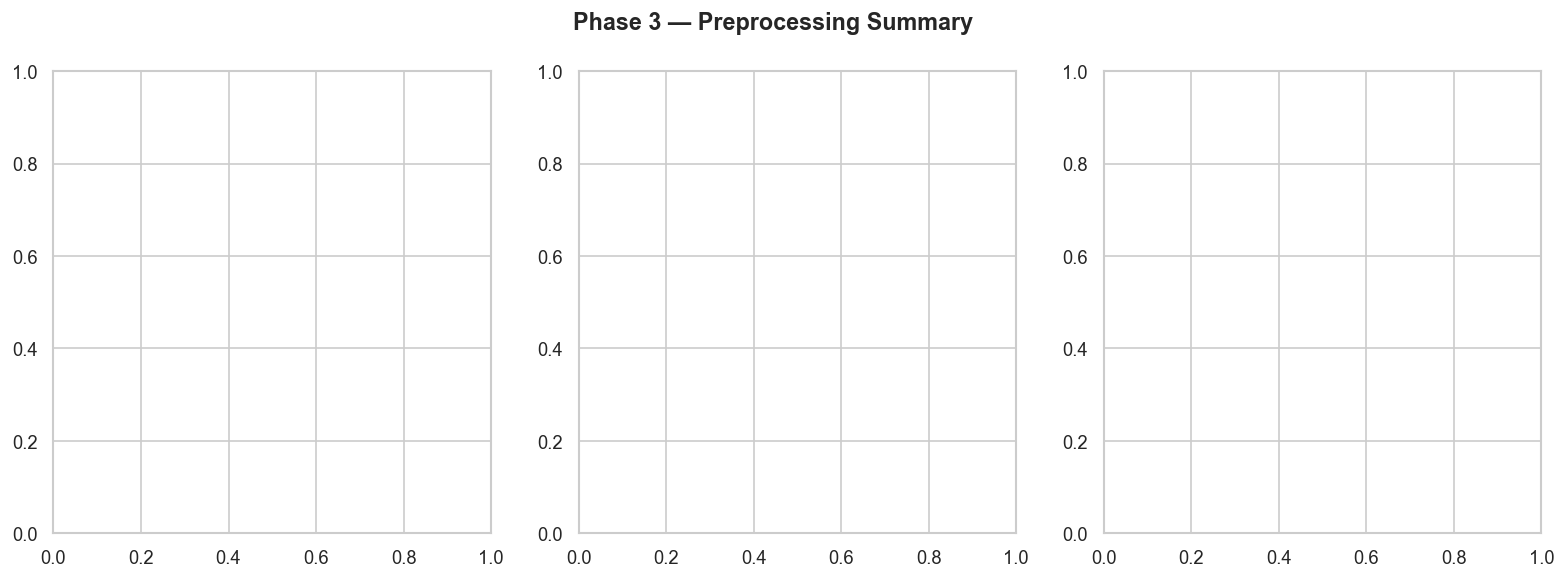

In [26]:
# ─────────────────────────────────────────────────────────────
#  STEP 11 — Visualize Preprocessing Results
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Phase 3 — Preprocessing Summary', fontsize=14, fontweight='bold')
 

In [27]:
# Plot 1: Before vs After SMOTE
labels = ['No Churn', 'Churn']
before = [(y_train == 0).sum(), (y_train == 1).sum()]
after  = [(y_train_res == 0).sum(), (y_train_res == 1).sum()]
x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, before, w, label='Before SMOTE', color='#E24B4A', alpha=0.8, edgecolor='white')
axes[0].bar(x + w/2, after,  w, label='After SMOTE',  color='#1D9E75', alpha=0.8, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_title('Class Balance: Before vs After SMOTE', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend()
sns.despine(ax=axes[0])
 

In [28]:
# Plot 2: Feature count
feature_types = {
    'Original\nNumeric': 4,
    'Original\nBinary': 7,
    'Original\nCategorical\n(encoded)': 3,
    'New\nEngineered': 5
}
colors = ['#185FA5', '#1D9E75', '#EF9F27', '#9B3EC2']
bars = axes[1].bar(feature_types.keys(), feature_types.values(),
                    color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, feature_types.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Feature Breakdown', fontweight='bold')
axes[1].set_ylabel('Number of Features')
axes[1].set_ylim(0, 9)
sns.despine(ax=axes[1])
 

In [29]:
# Plot 3: Engineered feature — TotalServices distribution
axes[2].hist(
    [X_train[y_train == 0]['TotalServices'],
     X_train[y_train == 1]['TotalServices']],
    bins=7, label=['No Churn', 'Churn'],
    color=['#1D9E75', '#E24B4A'], alpha=0.7, edgecolor='white'
)
axes[2].set_title('Engineered Feature: TotalServices', fontweight='bold')
axes[2].set_xlabel('Number of Add-on Services')
axes[2].set_ylabel('Count')
axes[2].legend()
sns.despine(ax=axes[2])
 
plt.tight_layout()
plt.savefig('phase3_preprocessing.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved as phase3_preprocessing.png\n")
 

<Figure size 768x576 with 0 Axes>

✅ Chart saved as phase3_preprocessing.png



In [30]:
# ─────────────────────────────────────────────────────────────
#  STEP 12 — Save processed data for Phase 4 (Model Building)
# ─────────────────────────────────────────────────────────────
import joblib
 
# Save splits
joblib.dump((X_train_res, X_test, y_train_res, y_test), 'processed_data.pkl')
joblib.dump(scaler, 'scaler.pkl')
 
print("✅ Processed data saved:")
print("   processed_data.pkl  → (X_train_res, X_test, y_train_res, y_test)")
print("   scaler.pkl          → fitted StandardScaler\n")
 

✅ Processed data saved:
   processed_data.pkl  → (X_train_res, X_test, y_train_res, y_test)
   scaler.pkl          → fitted StandardScaler



In [31]:
# ─────────────────────────────────────────────────────────────
#  FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  PHASE 3 COMPLETE — PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n  Original shape       : (7043, 20)")
print(f"  After preprocessing  : {X.shape[1]} features")
print(f"\n  Training set (SMOTE) : {X_train_res.shape[0]} rows (balanced)")
print(f"  Test set             : {X_test.shape[0]} rows (original ratio)")
print(f"\n  Steps completed:")
print("   1. Dropped customerID")
print("   2. Label Encoded 6 binary Yes/No columns")
print("   3. Cleaned 'No internet/phone service' → 'No'")
print("   4. Encoded 7 internet/phone service columns")
print("   5. One-Hot Encoded InternetService, Contract, PaymentMethod")
print("   6. Engineered 5 new features")
print("   7. StandardScaled 4 numeric columns")
print("   8. 80/20 stratified train-test split")
print("   9. Applied SMOTE to balance training classes")
print("\n  → Ready for Phase 4: Model Building\n")
 

  PHASE 3 COMPLETE — PREPROCESSING SUMMARY

  Original shape       : (7043, 20)
  After preprocessing  : 28 features

  Training set (SMOTE) : 8278 rows (balanced)
  Test set             : 1409 rows (original ratio)

  Steps completed:
   1. Dropped customerID
   2. Label Encoded 6 binary Yes/No columns
   3. Cleaned 'No internet/phone service' → 'No'
   4. Encoded 7 internet/phone service columns
   5. One-Hot Encoded InternetService, Contract, PaymentMethod
   6. Engineered 5 new features
   7. StandardScaled 4 numeric columns
   8. 80/20 stratified train-test split
   9. Applied SMOTE to balance training classes

  → Ready for Phase 4: Model Building

